# Probing Classifiers: Hands-On with Qwen2.5-0.5B

This notebook demonstrates **probing classifiers** — a mechanistic interpretability technique that trains small, simple models on a neural network's internal activations to discover what information is encoded at each layer.

We will:
1. Load Qwen2.5-0.5B and extract hidden-state activations from every layer
2. Train linear probes (logistic regression) to predict **sentiment** from each layer's activations
3. Visualize how sentiment information builds up across layers
4. Discuss what the results tell us — and what they don't

## 1. Setup and Model Loading

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "Qwen/Qwen2.5-0.5B"

print(f"Using device: {DEVICE}")
print(f"Loading model: {MODEL_NAME}")

c:\Research\axiom-rl-private\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.10.0+cu128
CUDA available: True
Using device: cuda
Loading model: Qwen/Qwen2.5-0.5B


In [2]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    output_hidden_states=True,
    torch_dtype=torch.float32,
).to(DEVICE)
model.eval()

num_layers = model.config.num_hidden_layers
hidden_size = model.config.hidden_size
print(f"Model loaded: {num_layers} layers, hidden size = {hidden_size}")

`torch_dtype` is deprecated! Use `dtype` instead!
The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 290/290 [00:01<00:00, 278.97it/s, Materializing param=model.norm.weight]                              


Model loaded: 24 layers, hidden size = 896


## 2. Sentiment Dataset

We create a small labeled dataset of clearly positive and clearly negative sentences.
For a real study you'd use a larger benchmark (SST-2, IMDB, etc.), but this is enough to demonstrate the technique.

In [3]:
positive_sentences = [
    "This movie was absolutely wonderful and I loved every minute of it.",
    "The food at the restaurant was delicious and the service was excellent.",
    "I had a fantastic time at the concert, the band was incredible.",
    "The book was beautifully written and deeply moving.",
    "What a gorgeous sunny day, perfect for a walk in the park.",
    "The team played brilliantly and deserved their victory.",
    "I'm so grateful for my amazing friends who always support me.",
    "The new software update is smooth, fast, and really well designed.",
    "This vacation was the best experience of my entire life.",
    "The students did an outstanding job on their final project.",
    "I feel happy and optimistic about the future.",
    "The garden looks absolutely beautiful this time of year.",
    "She gave a brilliant presentation that impressed everyone.",
    "The puppy is adorable and brings joy to the whole family.",
    "We had a wonderful celebration with great music and laughter.",
    "The sunrise this morning was breathtaking and peaceful.",
    "His kindness and generosity inspire everyone around him.",
    "The new cafe downtown has the most delightful pastries.",
    "I just got promoted and I'm thrilled about the opportunity.",
    "The children were laughing and playing happily together.",
    "This is the most comfortable chair I have ever sat in.",
    "The orchestra performance was flawless and deeply moving.",
    "I love spending time with my family during the holidays.",
    "The weather has been perfect all week, warm and sunny.",
    "Our team collaboration has been productive and rewarding.",
]

negative_sentences = [
    "This movie was terrible and a complete waste of time.",
    "The food was disgusting and the waiter was extremely rude.",
    "I had an awful experience at the hotel, nothing worked properly.",
    "The book was poorly written and painfully boring to read.",
    "What a miserable rainy day, everything went wrong.",
    "The team played horribly and deserved to lose the match.",
    "I'm so frustrated with my coworkers who constantly let me down.",
    "The new software update is buggy, slow, and crashes constantly.",
    "This trip was the worst experience I have ever had.",
    "The students failed miserably on their final examination.",
    "I feel anxious and pessimistic about what lies ahead.",
    "The yard is overgrown and looks completely neglected.",
    "He gave a terrible presentation that confused everyone.",
    "The stray dog is aggressive and scares all the neighbors.",
    "The party was a disaster with bad music and constant arguing.",
    "The storm this morning was frightening and destructive.",
    "His selfishness and cruelty hurt everyone around him.",
    "The old diner downtown has the most unappetizing food.",
    "I just got fired and I'm devastated about losing my job.",
    "The children were crying and fighting with each other.",
    "This is the most uncomfortable seat I have ever endured.",
    "The concert was painfully loud and completely disorganized.",
    "I dread spending time with relatives during the holidays.",
    "The weather has been freezing and miserable all week.",
    "Our group project has been chaotic and deeply frustrating.",
]

sentences = positive_sentences + negative_sentences
labels = np.array([1] * len(positive_sentences) + [0] * len(negative_sentences))

print(f"Dataset: {len(positive_sentences)} positive + {len(negative_sentences)} negative = {len(sentences)} total")

Dataset: 25 positive + 25 negative = 50 total


## 3. Extract Hidden States from Every Layer

We pass each sentence through Qwen and save the hidden-state vector at every layer.
We use the **mean of all token positions** as the sentence representation (mean pooling).

In [4]:
def extract_hidden_states(sentences, model, tokenizer, device):
    """Extract mean-pooled hidden states from all layers for each sentence."""
    # num_layers + 1 because output_hidden_states includes the embedding layer (layer 0)
    all_hidden = {layer: [] for layer in range(model.config.num_hidden_layers + 1)}

    with torch.no_grad():
        for sent in sentences:
            inputs = tokenizer(sent, return_tensors="pt", truncation=True, max_length=128).to(device)
            outputs = model(**inputs)

            # outputs.hidden_states is a tuple: (embedding_output, layer_1, layer_2, ..., layer_N)
            for layer_idx, hidden_state in enumerate(outputs.hidden_states):
                # hidden_state shape: (1, seq_len, hidden_size)
                # Mean-pool across the sequence dimension
                mean_repr = hidden_state.squeeze(0).mean(dim=0).cpu().numpy()
                all_hidden[layer_idx].append(mean_repr)

    # Convert lists to numpy arrays
    for layer_idx in all_hidden:
        all_hidden[layer_idx] = np.array(all_hidden[layer_idx])

    return all_hidden


print("Extracting hidden states from all layers...")
hidden_states = extract_hidden_states(sentences, model, tokenizer, DEVICE)
print(f"Done. Extracted activations for {len(hidden_states)} layers (embedding + {num_layers} transformer layers).")
print(f"Each layer: shape = {hidden_states[0].shape}  (samples x hidden_size)")

Extracting hidden states from all layers...
Done. Extracted activations for 25 layers (embedding + 24 transformer layers).
Each layer: shape = (50, 896)  (samples x hidden_size)


## 4. Train Probing Classifiers

For each layer, we train a **logistic regression** classifier to predict sentiment from the hidden-state vectors.
We use 5-fold cross-validation to get robust accuracy estimates.

Logistic regression is a good choice for probes because:
- It's linear, so it can only use information that's **linearly encoded** in the activations
- It has very few parameters, so it's unlikely to learn the task on its own
- It's fast to train

In [5]:
layer_accuracies = []
layer_names = []

print(f"Training probes on {len(hidden_states)} layers (5-fold cross-validation)...\n")
print(f"{'Layer':<15} {'Mean Accuracy':>15} {'Std':>10}")
print("-" * 42)

for layer_idx in range(len(hidden_states)):
    X = hidden_states[layer_idx]

    # Standardize features — important for logistic regression
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train logistic regression probe with cross-validation
    probe = LogisticRegression(max_iter=1000, solver="lbfgs", C=1.0)
    scores = cross_val_score(probe, X_scaled, labels, cv=5, scoring="accuracy")

    mean_acc = scores.mean()
    std_acc = scores.std()
    layer_accuracies.append(mean_acc)

    name = "Embedding" if layer_idx == 0 else f"Layer {layer_idx}"
    layer_names.append(name)

    print(f"{name:<15} {mean_acc:>14.1%} {std_acc:>9.1%}")

print(f"\nBest layer: {layer_names[np.argmax(layer_accuracies)]} ({max(layer_accuracies):.1%})")

Training probes on 25 layers (5-fold cross-validation)...

Layer             Mean Accuracy        Std
------------------------------------------
Embedding                90.0%     11.0%
Layer 1                  94.0%      8.0%
Layer 2                  94.0%      8.0%
Layer 3                  96.0%      8.0%
Layer 4                  98.0%      4.0%
Layer 5                  98.0%      4.0%
Layer 6                  98.0%      4.0%
Layer 7                  98.0%      4.0%
Layer 8                  98.0%      4.0%
Layer 9                  98.0%      4.0%
Layer 10                100.0%      0.0%
Layer 11                100.0%      0.0%
Layer 12                100.0%      0.0%
Layer 13                100.0%      0.0%
Layer 14                100.0%      0.0%
Layer 15                100.0%      0.0%
Layer 16                100.0%      0.0%
Layer 17                100.0%      0.0%
Layer 18                 98.0%      4.0%
Layer 19                100.0%      0.0%
Layer 20                 98.0%     

## 5. Visualize: How Sentiment Information Builds Across Layers

This is the key result. The plot shows probe accuracy at each layer — higher accuracy means the layer encodes more linearly-separable sentiment information.

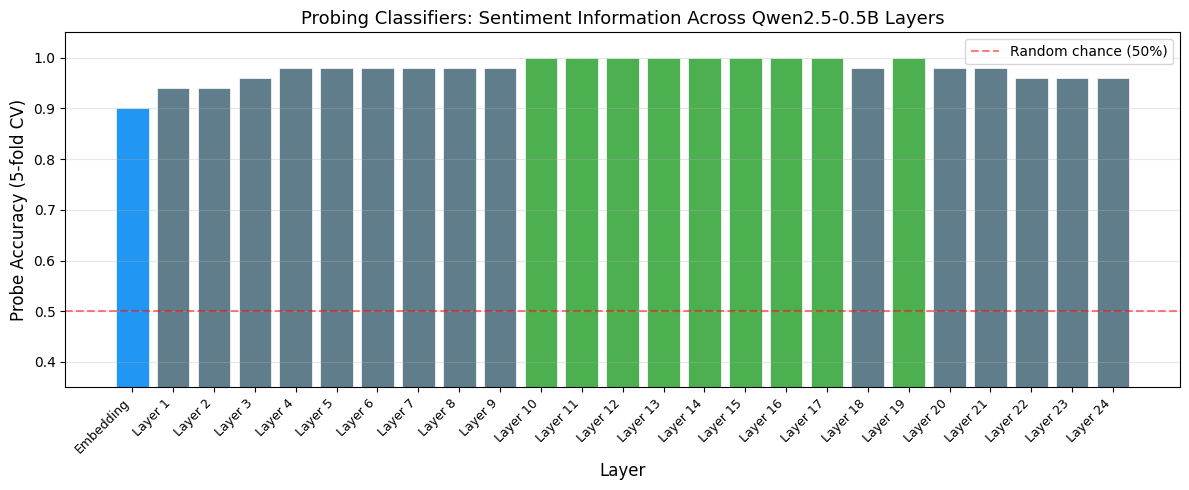

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

layer_indices = list(range(len(layer_accuracies)))
colors = ['#2196F3' if i == 0 else '#4CAF50' if acc >= max(layer_accuracies) - 0.01 else '#607D8B'
          for i, acc in enumerate(layer_accuracies)]

bars = ax.bar(layer_indices, layer_accuracies, color=colors, edgecolor='white', linewidth=0.5)

ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random chance (50%)')
ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Probe Accuracy (5-fold CV)', fontsize=12)
ax.set_title('Probing Classifiers: Sentiment Information Across Qwen2.5-0.5B Layers', fontsize=13)
ax.set_xticks(layer_indices)
ax.set_xticklabels(layer_names, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0.35, 1.05)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Bonus: Probing for a Different Concept — Sentence Length

To illustrate that probes can test for **any** labelable concept, let's probe for something different: whether the sentence is short or long. This helps show that probing is a general tool, not specific to sentiment.

In [7]:
# Create binary labels: short (below median) vs. long (above median)
word_counts = np.array([len(s.split()) for s in sentences])
median_length = np.median(word_counts)
length_labels = (word_counts > median_length).astype(int)

print(f"Median word count: {median_length}")
print(f"Short sentences: {(length_labels == 0).sum()}, Long sentences: {(length_labels == 1).sum()}")

length_accuracies = []
print(f"\n{'Layer':<15} {'Mean Accuracy':>15}")
print("-" * 32)

for layer_idx in range(len(hidden_states)):
    X = hidden_states[layer_idx]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    probe = LogisticRegression(max_iter=1000, solver="lbfgs", C=1.0)
    scores = cross_val_score(probe, X_scaled, length_labels, cv=5, scoring="accuracy")
    length_accuracies.append(scores.mean())

    name = "Embedding" if layer_idx == 0 else f"Layer {layer_idx}"
    print(f"{name:<15} {scores.mean():>14.1%}")

Median word count: 10.0
Short sentences: 38, Long sentences: 12

Layer             Mean Accuracy
--------------------------------
Embedding                74.0%
Layer 1                  72.0%
Layer 2                  74.0%
Layer 3                  80.0%
Layer 4                  80.0%
Layer 5                  78.0%
Layer 6                  76.0%
Layer 7                  74.0%
Layer 8                  76.0%
Layer 9                  78.0%
Layer 10                 82.0%
Layer 11                 78.0%
Layer 12                 78.0%
Layer 13                 76.0%
Layer 14                 80.0%
Layer 15                 72.0%
Layer 16                 70.0%
Layer 17                 72.0%
Layer 18                 68.0%
Layer 19                 68.0%
Layer 20                 68.0%
Layer 21                 68.0%
Layer 22                 62.0%
Layer 23                 64.0%
Layer 24                 66.0%


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(layer_indices, layer_accuracies, 'o-', color='#4CAF50', linewidth=2, markersize=6, label='Sentiment')
ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
ax1.set_xlabel('Layer')
ax1.set_ylabel('Probe Accuracy')
ax1.set_title('Sentiment Probe')
ax1.set_xticks(layer_indices)
ax1.set_xticklabels(layer_names, rotation=45, ha='right', fontsize=8)
ax1.set_ylim(0.35, 1.05)
ax1.grid(alpha=0.3)

ax2.plot(layer_indices, length_accuracies, 's-', color='#FF9800', linewidth=2, markersize=6, label='Length')
ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('Layer')
ax2.set_ylabel('Probe Accuracy')
ax2.set_title('Sentence Length Probe')
ax2.set_xticks(layer_indices)
ax2.set_xticklabels(layer_names, rotation=45, ha='right', fontsize=8)
ax2.set_ylim(0.35, 1.05)
ax2.grid(alpha=0.3)

fig.suptitle('Probing for Different Concepts in Qwen2.5-0.5B', fontsize=14, y=1.02)
plt.tight_layout()S
plt.show()

SyntaxError: invalid syntax (326668872.py, line 24)

## 7. Interpretation and Limitations

### What the results show
- **If sentiment probe accuracy increases in later layers**: The model progressively builds a representation of sentiment as information flows through the network. This mirrors findings in image classifiers (ResNet-50) where classification accuracy improves steadily across layers.
- **If certain layers have sudden jumps**: That layer may perform a critical computation that transforms raw token representations into something more semantically meaningful.
- **If the length probe shows a different pattern**: Different concepts are encoded differently, confirming that probing can distinguish what information is present where.

### What the results do NOT show
- **We do not know if Qwen *uses* sentiment information in its outputs.** A probe tells us sentiment is *present* in the activations — not that the model relies on it. The information could be incidental.
- **The probe's accuracy depends on the probe itself.** A linear probe can only detect linearly separable information. If sentiment is encoded non-linearly, we would underestimate it. A more complex probe might detect it — but then we can't tell if the probe is reading the model's activations or solving the task on its own.
- **50 sentences is small.** A full study would use thousands of examples and control for confounds (sentence length, vocabulary overlap, etc.).

### Connection to AI Safety
Probing classifiers are a **first-pass tool** for mechanistic interpretability. They help answer: *does this model encode concept X?* and *where?* This is useful for:
- Checking whether a model internally represents dangerous knowledge even when it refuses to output it
- Detecting cases where internal representations diverge from stated outputs (potential deception)
- Guiding more targeted interpretability methods (activation patching, causal tracing) to the right layers

But they cannot replace causal methods. Knowing that information is *present* is not the same as knowing it is *used*.